In [2]:
library(Seurat)
library(scop)
library(Signac)
library(ggplot2)
set.seed(4180)
setwd("/")
#########color
cols <- c("#444576", "#4682B4",
 "#AEDEEE","#FFA500",
 "#FFD790","#C65762","#FBDFDE",
 "#F6EFCF","#BCB99F")
pal <- colorRampPalette(cols)

Loading required package: SeuratObject

Loading required package: sp




Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


Registered S3 method overwritten by 'scop':
  method             from  
  FoldChange.default Seurat

          ⬢          .        ⬡             ⬢     .
                     _____ _________  ____
                    / ___// ___/ __ ./ __ .
                   (__  )/ /__/ /_/ / /_/ /
                  /____/ .___/.____/ .___/
                                  /_/
      ⬢               .      ⬡        .          ⬢

------------------------------------------------------------
Version: 0.8.7 (2026-03-31 update)
Website: https://mengxu98.github.io/scop/

Python environment initialization is disabled
To enable it, set: options(scop_env_init = TRUE)

The message can be suppressed by: 
  suppressPackageStartupMessages(library(scop))
  or options(log_message.verbose = FALSE)
------------------------------------------------------------



In [3]:
vCM <- readRDS("data/vCM.Rds")
DefaultAssay(vCM) <- "RNA"

In [9]:
vCM[["activity"]] <- readRDS("data/activity.Rds")[,colnames(vCM)][["activity"]]

In [3]:
library(ggraph)
library(tidygraph)
library(igraph)
library(ggplot2)
library(FigR)
library(dplyr)
library(Hmisc)
library(FigR)
figR.d <- readRDS("data/vCM2_figR.rds")
obj <- subset(vCM,subtype %in% c("vCM-2"))
obj[["aUCell"]] <- readRDS("data/ge_AUCell.Rds")[,colnames(obj)][["AUCell"]]
obj[["motif"]] <- readRDS("data/motif.Rds")[,colnames(obj)][["motif"]]
ranklist <- rankDrivers(figR.d,rankBy = "meanScore")$data
rownames(ranklist) <- ranklist$Motif
DefaultAssay(obj) <- 'aUCell'
obj[["aUCell"]] <- as(obj[["aUCell"]],Class = "Assay5")
rownames(obj) <- tolower(gsub("-", " ", gsub("GOBP-", "", rownames(obj))))


Attaching package: ‘ggraph’


The following object is masked from ‘package:sp’:

    geometry



Attaching package: ‘tidygraph’


The following object is masked from ‘package:stats’:

    filter



Attaching package: ‘igraph’


The following object is masked from ‘package:tidygraph’:

    groups


The following object is masked from ‘package:Seurat’:

    components


The following objects are masked from ‘package:stats’:

    decompose, spectrum


The following object is masked from ‘package:base’:

    union


Loading required package: Matrix

Loading required package: SummarizedExperiment

Loading required package: MatrixGenerics

Loading required package: matrixStats


Attaching package: ‘MatrixGenerics’


The following objects are masked from ‘package:matrixStats’:

    colAlls, colAnyNAs, colAnys, colAvgsPerRowSet, colCollapse,
    colCounts, colCummaxs, colCummins, colCumprods, colCumsums,
    colDiffs, colIQRDiffs, colIQRs, colLogSumExps, colMadDiffs,
    colMads, colMaxs, col

In [14]:
rownames(obj)[grepl("triphosphate biosynthetic process", rownames(obj))]

[1] "nucleoside triphosphate biosynthetic process"               
[2] "pyrimidine nucleoside triphosphate biosynthetic process"    
[3] "pyrimidine ribonucleoside triphosphate biosynthetic process"

Warning message:
“Removed 174 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 174 rows containing missing values or values outside the scale range
(`geom_point()`).”


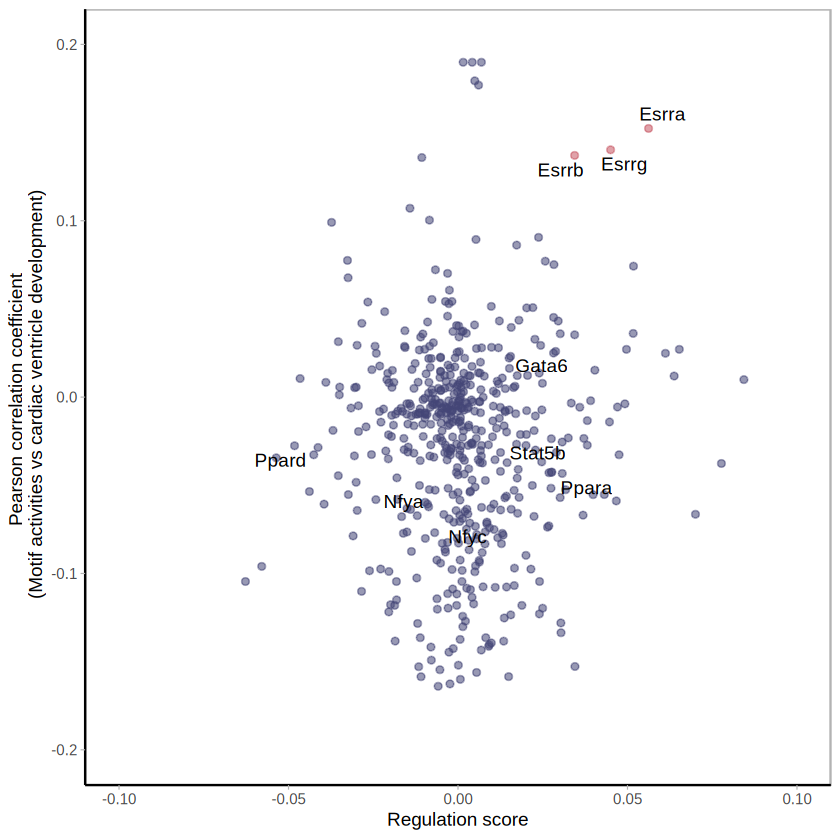

In [8]:
#S5a
dt <- data.frame(t(GetAssayData(obj,assay = 'motif',layer = 'data')[ranklist$Motif,]),
 cardiac = GetAssayData(obj,assay = 'aUCell',layer = 'data')['cardiac ventricle development',])
res <- rcorr(as.matrix(dt),type	= 'pearson')
res_p <- res$P
plot.dt <- data.frame(score = ranklist[colnames(dt),]$Score,cor_r= res$r[,'cardiac'],genes = colnames(dt) )
plot.dt$color <- ifelse(plot.dt$genes %in% c('Esrra','Esrrg','Esrrb'),'ERR','Others')
esrra_data <- subset(plot.dt, genes %in% c('Esrra','Esrrg','Esrrb','Ppara','Ppard','Stat5b','Gata6','Nfyc','Nfya'))
p<- ggplot(data = plot.dt, mapping = aes(x = score, y = cor_r, color = color)) +
 geom_point(aes(alpha = 0.5)) +
 xlim(-0.1, 0.1) +
 ylim(-0.2, 0.2) +
 theme_light() +
 geom_text_repel(
 data = esrra_data, # subset data
 aes(label = genes), # label content
 color = "black", # labelcolors(distinct from points)
 size = 4)+
 scale_color_manual(values = c('#C65762','#444576')) +
 theme(
 panel.grid.major = element_blank(), # remove major gridlines
 panel.grid.minor = element_blank(), # remove minor gridlines
 axis.line = element_line(color = "black"),
 legend.position = 'None') +
 xlab('Regulation score')+ylab('Pearson correlation coefficient \n (Motif activities vs cardiac ventricle development)')
p
ggsave(plot = p, filename = "figS5a_cardiac ventricle development.pdf",path = "plot/figureS5/", width = 4.5, height =4,create.dir = T)

Warning message:
“Removed 174 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 174 rows containing missing values or values outside the scale range
(`geom_point()`).”


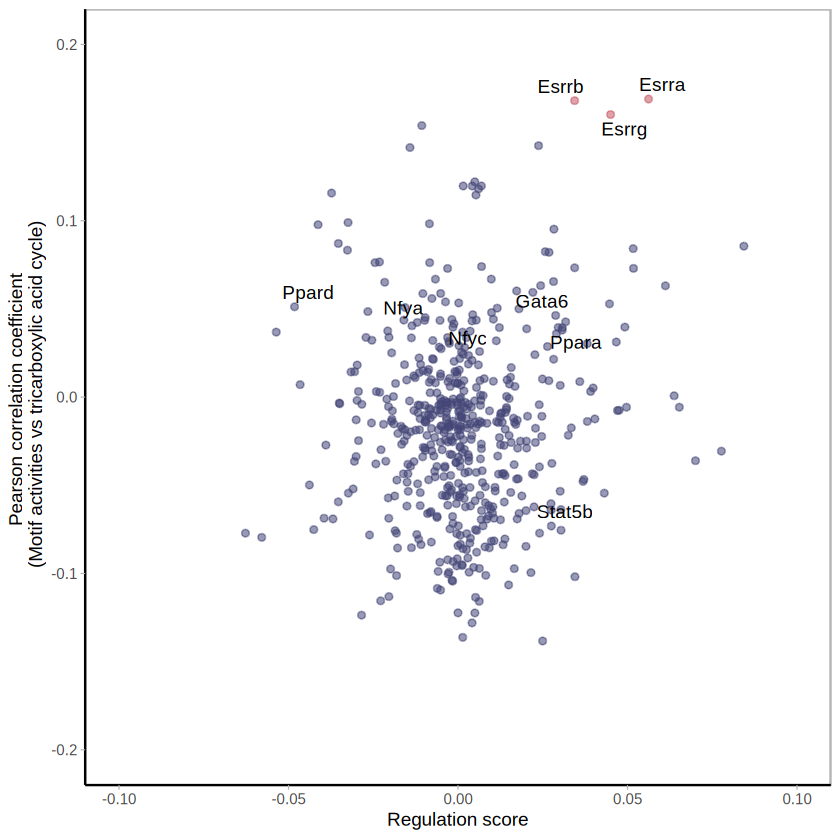

In [12]:
dt <- data.frame(t(GetAssayData(obj,assay = 'motif',layer = 'data')[ranklist$Motif,]),
 cardiac = GetAssayData(obj,assay = 'aUCell',layer = 'data')['tricarboxylic acid cycle',])
res <- rcorr(as.matrix(dt),type	= 'pearson')
res_p <- res$P
plot.dt <- data.frame(score = ranklist[colnames(dt),]$Score,cor_r= res$r[,'cardiac'],genes = colnames(dt) )
plot.dt$color <- ifelse(plot.dt$genes %in% c('Esrra','Esrrg','Esrrb'),'ERR','Others')
esrra_data <- subset(plot.dt, genes %in% c('Esrra','Esrrg','Esrrb','Ppara','Ppard','Stat5b','Gata6','Nfyc','Nfya'))
p<- ggplot(data = plot.dt, mapping = aes(x = score, y = cor_r, color = color)) +
 geom_point(aes(alpha = 0.5)) +
 xlim(-0.1, 0.1) +
 ylim(-0.2, 0.2) +
 theme_light() +
 geom_text_repel(
 data = esrra_data, # subset data
 aes(label = genes), # label content
 color = "black", # labelcolors(distinct from points)
 size = 4)+
 scale_color_manual(values = c('#C65762','#444576')) +
 theme(
 panel.grid.major = element_blank(), # remove major gridlines
 panel.grid.minor = element_blank(), # remove minor gridlines
 axis.line = element_line(color = "black"),
 legend.position = 'None') +
 xlab('Regulation score')+ylab('Pearson correlation coefficient \n (Motif activities vs tricarboxylic acid cycle)')
p
ggsave(plot = p, filename = "figS5a_tricarboxylic_acid_cycle.pdf",path = "plot/figureS5/", width = 4.5, height =4,create.dir = T)

Warning message:
“Removed 174 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 174 rows containing missing values or values outside the scale range
(`geom_point()`).”


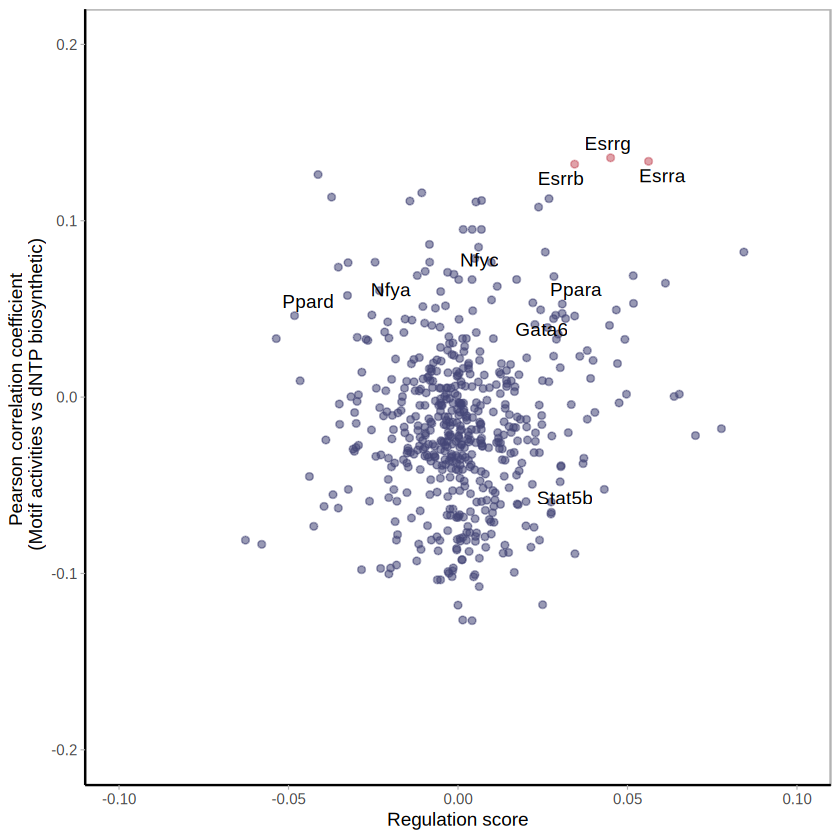

In [15]:
dt <- data.frame(t(GetAssayData(obj,assay = 'motif',layer = 'data')[ranklist$Motif,]),
 cardiac = GetAssayData(obj,assay = 'aUCell',layer = 'data')['nucleoside triphosphate biosynthetic process',])
res <- rcorr(as.matrix(dt),type	= 'pearson')
res_p <- res$P
plot.dt <- data.frame(score = ranklist[colnames(dt),]$Score,cor_r= res$r[,'cardiac'],genes = colnames(dt) )
plot.dt$color <- ifelse(plot.dt$genes %in% c('Esrra','Esrrg','Esrrb'),'ERR','Others')
esrra_data <- subset(plot.dt, genes %in% c('Esrra','Esrrg','Esrrb','Ppara','Ppard','Stat5b','Gata6','Nfyc','Nfya'))
p<- ggplot(data = plot.dt, mapping = aes(x = score, y = cor_r, color = color)) +
 geom_point(aes(alpha = 0.5)) +
 xlim(-0.1, 0.1) +
 ylim(-0.2, 0.2) +
 theme_light() +
 geom_text_repel(
 data = esrra_data, # subset data
 aes(label = genes), # label content
 color = "black", # labelcolors(distinct from points)
 size = 4)+
 scale_color_manual(values = c('#C65762','#444576')) +
 theme(
 panel.grid.major = element_blank(), # remove major gridlines
 panel.grid.minor = element_blank(), # remove minor gridlines
 axis.line = element_line(color = "black"),
 legend.position = 'None') +
 xlab('Regulation score')+ylab('Pearson correlation coefficient \n (Motif activities vs dNTP biosynthetic)')
p
ggsave(plot = p, filename = "figS5a_dNTP_biosynthetic.pdf",path = "plot/figureS5/", width = 4.5, height =4,create.dir = T)

In [28]:
geneList <- filter(figR.d,Motif %in% c('Esrra') & c(Score > 0.3 | Score < -0.3))
geneList$DORC

[1] "Ablim2"        "Acacb"         "Actc1"         "Actg1"        
 [5] "Adamts1"       "Arhgap10"      "Arrdc2"        "Bcl2l11"      
 [9] "Ccdc141"       "Corin"         "Coro1c"        "Cyfip2"       
[13] "D630024D03Rik" "Daam1"         "Dag1"          "Dlc1"         
[17] "Dusp5"         "Ehd4"          "Elmsan1"       "Fgf1"         
[21] "Fgf13"         "Fnbp1"         "Fosl2"         "Foxo3"        
[25] "Gpam"          "Grm1"          "Gse1"          "Kif5b"        
[29] "Map7"          "Mbd2"          "Mgll"          "Mylk3"        
[33] "Mylk4"         "Myom1"         "Mypn"          "Myzap"        
[37] "Nppb"          "Nuak1"         "Ogdh"          "Optn"         
[41] "Osbpl3"        "Oxct1"         "Pik3r1"        "Pitpnm2"      
[45] "Ppp1r3a"       "Prune2"        "Psme4"         "Pxdn"         
[49] "Rap1gap2"      "Rbms1"         "Rere"          "Rock2"        
[53] "Sbk1"          "Scarb2"        "Sh3bgr"        "Slc47a1"      
[57] "Snta1"         "Snx24"         "Sorbs1"        "St3gal1"      
[61] "Stat3"         "Stk39"         "Tbc1d8"        "Tead1"        
[65] "Tnfaip8"       "Tsc22d3"       "Ttc7"          "Ttn"          
[69] "Ucp3"          "Vwa8"          "Wasf2"         "Whrn"         
[73] "Wipf3"         "Zbtb16"

In [17]:
figR.d <- readRDS(paste("data/vCM2_","MP","_figR.rds",sep = ""))

Ranking TFs by mean regulation score across all DORCs ..


Warning message in geom_bar(size = 0.1, stat = "identity", fill = "darkorange", :
“Ignoring unknown parameters: `size`”


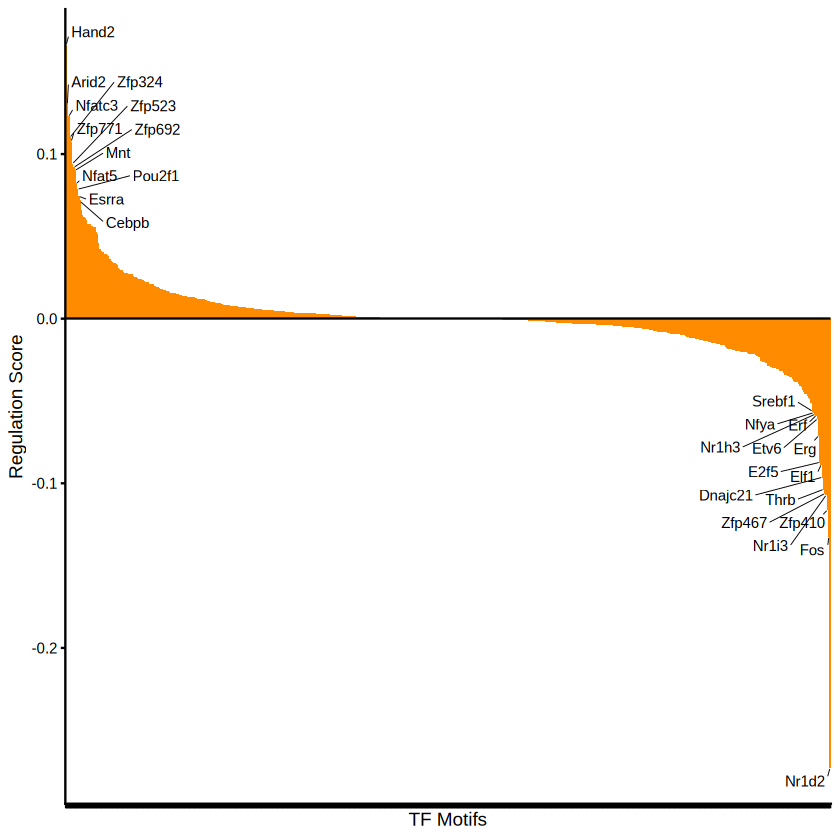

In [18]:
rankDrivers(figR.d,rankBy = "meanScore")

In [39]:
##cytoscape
library(ggraph)
library(tidygraph)
library(igraph)
library(ggplot2)
library(FigR)
library(dplyr)
library(Hmisc)
library(FigR)
vCM@active.ident <- factor(vCM$group)
#
obj <- subset(vCM,subtype %in% "vCM-2")
for(i in c("EP","MP","LP")){
figR.d <- readRDS(paste("data/vCM2_",i,"figR.rds",sep = ""))
geneList <- filter(figR.d, Motif %in% c('Esrra'))
allmarkers_RNA <- FindMarkers(obj,group.by = 'group' ,assay = 'RNA',slot='data',ident.1 = i,ident.2 = 'NP',min.pct = 0, logfc.threshold = 0)
allmarkers_activities <- FindMarkers(obj,group.by = 'group' ,assay = 'activity',slot='data',ident.1 = i,ident.2 = 'NP',min.pct = 0.2, logfc.threshold = 0)
node_data <- data.frame(RNA=allmarkers_RNA[unique(c(geneList$DORC,geneList$Motif)),]$avg_log2FC,
 peak=allmarkers_activities[unique(c(geneList$DORC,geneList$Motif)),]$avg_log2FC,
 pct=allmarkers_RNA[unique(c(geneList$DORC,geneList$Motif)),]$pct.1,
 row.names =unique(c(geneList$DORC,geneList$Motif)))
node_data$case <- ifelse((node_data$RNA < 0 & node_data$peak < 0) | (node_data$RNA > 0 & node_data$peak > 0), TRUE, FALSE ) 
write.csv(node_data, paste(i,"node_data.csv",sep="_"))
}

In [50]:
vCM <- readRDS("data/vCM.Rds")
DefaultAssay(vCM) <- "RNA"

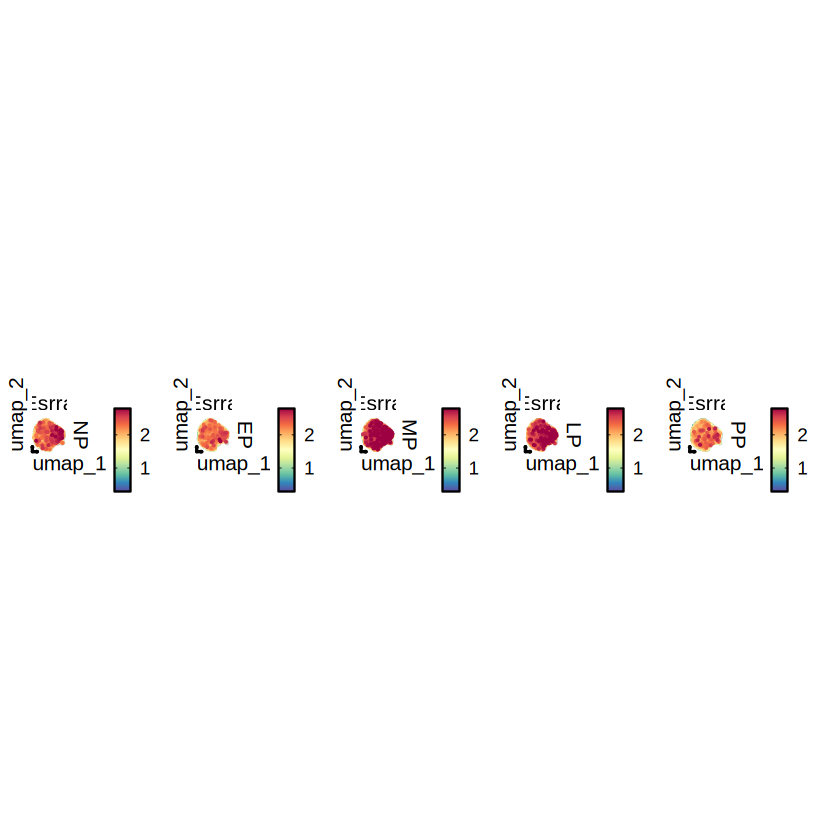

In [51]:
FeatureDimPlot(vCM,features = 'Esrra',split.by = 'group',ncol = 5,theme_use = "theme_blank")

In [53]:
p2 <- FeatureDimPlot(vCM,features = 'Esrra',split.by = 'group',ncol = 5,theme_use = "theme_blank")+ patchwork::plot_layout(
 guides = "collect"
)
ggsave(
 plot = p2, filename = "S5c_vCM_Esrra.pdf", path = "plot/figureS5/",
 create.dir = TRUE, width = 10, height = 3
)
p1 <- FeatureDimPlot(subset(vCM,subtype %in% "vCM-2"),features = 'Esrra',split.by = 'group',ncol = 5,theme_use = "theme_blank")+ patchwork::plot_layout(
 guides = "collect"
)
ggsave(
 plot = p1, filename = "S5c_vCM2_Esrra.pdf", path = "plot/figureS5/",
 create.dir = TRUE, width = 10, height = 3
)